# TextRank cho một tài liệu và trực quan hóa đồ thị

Notebook này chỉ xử lý **một file DUC** (`d061j`). Kết quả gồm candidate summary, thống kê, biểu đồ điểm PageRank và mạng liên kết giữa các câu nổi bật.

> Mỗi nút là một câu. Cạnh biểu diễn cosine similarity đạt ngưỡng; nút màu cam là câu được chọn vào summary.

## 1. Thiết lập

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from bs4 import BeautifulSoup

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

FILE_TXT_PATH = PROJECT_ROOT / 'data' / 'DUC_TEXT' / 'train' / 'd061j'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'output' / 'single-document-textrank-visualization'

SIMILARITY_THRESHOLD = 0.10
PAGERANK_DAMPING = 0.85
PAGERANK_TOLERANCE = 1e-8
PAGERANK_MAX_ITERATIONS = 1000
MAX_SUMMARY_WORDS = 100
USE_MMR = True
MMR_LAMBDA = 0.70
TOP_SENTENCES_TO_PLOT = 20

assert FILE_TXT_PATH.is_file(), f'Không tìm thấy file input: {FILE_TXT_PATH}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Input : {FILE_TXT_PATH}')
print(f'Output: {OUTPUT_DIR}')

Input : /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/DUC_TEXT/train/d061j
Output: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/single-document-textrank-visualization


## 2. Pipeline TextRank

In [2]:
# Sử dụng thư viện

STOP_WORDS = {
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'been', 'being', 'but', 'by',
    'for', 'from', 'had', 'has', 'have', 'he', 'her', 'hers', 'him', 'his',
    'i', 'if', 'in', 'into', 'is', 'it', 'its', 'no', 'not', 'of', 'on',
    'or', 'our', 'ours', 'she', 'so', 'that', 'the', 'their', 'theirs',
    'them', 'there', 'they', 'this', 'those', 'to', 'was', 'we', 'were',
    'what', 'when', 'where', 'which', 'who', 'will', 'with', 'would', 'you',
    'your', 'said', 'about', 'after', 'all', 'also', 'before', 'could',
    'more', 'most', 'other', 'over', 'than', 'then', 'up'
}

TOKEN_PATTERN = re.compile(r"[a-z]+(?:'[a-z]+)?|\d+")

def preprocess(text):
    all_tokens = TOKEN_PATTERN.findall(text.lower())

    filtered_tokens = []
    for token in all_tokens:
        if token not in STOP_WORDS:
            filtered_tokens.append(token)

    return filtered_tokens


def read_topic(topic_path):
    file_content = topic_path.read_text(encoding='utf-8')
    soup = BeautifulSoup(file_content, 'html.parser')
    sentences = []

    for sentence_tag in soup.find_all('s'):
        content = sentence_tag.get_text().strip()
        tokens = preprocess(content)

        if len(tokens) == 0:
            continue

        sentence = {}
        sentence['docid'] = str(sentence_tag.get('docid', ''))
        sentence['num'] = int(sentence_tag.get('num', 0)) # type: ignore
        sentence['wdcount'] = int(sentence_tag.get('wdcount', len(content.split()))) # type: ignore
        sentence['content'] = content
        sentence['tagged_content'] = str(sentence_tag)
        sentence['tokens'] = tokens
        sentence['source_index'] = len(sentences)
        sentences.append(sentence)

    return sentences

def calculate_tf(tokens):
    counts = {}
    for token in tokens:
        if token not in counts:
            counts[token] = 0
        counts[token] = counts[token] + 1

    token_count = len(tokens)
    tf = {}
    for term, count in counts.items():
        tf[term] = count / token_count
    return tf


def calculate_idf(tokenized_sentences):
    sentence_count = len(tokenized_sentences)
    document_frequency = {}

    for tokens in tokenized_sentences:
        unique_tokens = set(tokens)
        for term in unique_tokens:
            if term not in document_frequency:
                document_frequency[term] = 0
            document_frequency[term] = document_frequency[term] + 1

    idf = {}
    for term, frequency in document_frequency.items():
        numerator = 1 + sentence_count
        denominator = 1 + frequency
        idf[term] = math.log(numerator / denominator) + 1
    return idf


def l2_normalize(vector):
    squared_sum = 0.0
    for weight in vector.values():
        squared_sum = squared_sum + weight * weight
    norm = math.sqrt(squared_sum)
    if norm == 0.0:
        return {}

    normalized_vector = {}
    for term, weight in vector.items():
        normalized_vector[term] = weight / norm
    return normalized_vector


def calculate_tfidf_vectors(sentences):
    tokenized_sentences = []
    for sentence in sentences:
        tokenized_sentences.append(sentence['tokens'])

    idf = calculate_idf(tokenized_sentences)
    vectors = []
    for tokens in tokenized_sentences:
        tf = calculate_tf(tokens)
        vector = {}
        for term, tf_value in tf.items():
            vector[term] = tf_value * idf[term]
        vectors.append(l2_normalize(vector))
    return vectors

def cosine_similarity(left_vector, right_vector):
    similarity = 0.0
    for term, left_weight in left_vector.items():
        right_weight = right_vector.get(term, 0.0)
        similarity = similarity + left_weight * right_weight
    return similarity


def build_sentence_graph(vectors, similarity_threshold):
    sentence_count = len(vectors)

    graph = {}
    for index in range(sentence_count):
        graph[index] = {}

    similarities = []
    for row_index in range(sentence_count):
        row = [0.0] * sentence_count
        similarities.append(row)

    for left_index in range(sentence_count):
        for right_index in range(left_index + 1, sentence_count):
            similarity = cosine_similarity(vectors[left_index], vectors[right_index])
            similarities[left_index][right_index] = similarity
            similarities[right_index][left_index] = similarity
            if similarity >= similarity_threshold:
                graph[left_index][right_index] = similarity
                graph[right_index][left_index] = similarity

    return graph, similarities

def calculate_pagerank(
    graph,
    damping=0.85,
    tolerance=1e-8,
    max_iterations=1000,
):
    node_count = len(graph)
    if node_count == 0:
        return {}, 0
    if not 0.0 < damping < 1.0:
        raise ValueError('damping phải nằm trong khoảng (0, 1)')

    scores = {}
    outgoing_weights = {}
    for node, neighbors in graph.items():
        scores[node] = 1.0 / node_count
        outgoing_weights[node] = sum(neighbors.values())

    for iteration in range(1, max_iterations + 1):
        dangling_score = 0.0
        for node, total_weight in outgoing_weights.items():
            if total_weight == 0.0:
                dangling_score = dangling_score + scores[node]

        base_score = (1.0 - damping) / node_count
        dangling_share = damping * dangling_score / node_count

        new_scores = {}
        for node in graph:
            new_scores[node] = base_score + dangling_share

        for source, neighbors in graph.items():
            total_weight = outgoing_weights[source]
            if total_weight == 0.0:
                continue
            for target, edge_weight in neighbors.items():
                new_scores[target] += (
                    damping * scores[source] * edge_weight / total_weight
                )

        difference = 0.0
        for node in graph:
            score_change = abs(new_scores[node] - scores[node])
            difference = difference + score_change
        scores = new_scores
        if difference < tolerance:
            assert math.isclose(sum(scores.values()), 1.0, rel_tol=1e-9, abs_tol=1e-9)
            return scores, iteration

    raise RuntimeError(f'PageRank không hội tụ sau {max_iterations} vòng lặp')

def normalize_scores(scores):
    low = min(scores.values())
    high = max(scores.values())
    normalized_scores = {}

    if math.isclose(low, high):
        for index in scores:
            normalized_scores[index] = 1.0
        return normalized_scores

    for index, score in scores.items():
        normalized_scores[index] = (score - low) / (high - low)
    return normalized_scores


def select_sentences(
    sentences,
    pagerank_scores,
    similarities,
    max_words,
    use_mmr,
    mmr_lambda,
):
    relevance = normalize_scores(pagerank_scores)
    remaining = set(range(len(sentences)))
    selected = []
    used_words = 0

    while len(remaining) > 0:
        best_index = None
        best_comparison = None

        for index in remaining:
            sentence_words = len(sentences[index]['content'].split())
            if used_words + sentence_words > max_words:
                continue

            redundancy = 0.0
            if use_mmr and len(selected) > 0:
                for selected_index in selected:
                    similarity = similarities[index][selected_index]
                    if similarity > redundancy:
                        redundancy = similarity

            selection_score = relevance[index]
            if use_mmr:
                selection_score = (
                    mmr_lambda * relevance[index]
                    - (1.0 - mmr_lambda) * redundancy
                )

            comparison = (
                selection_score,
                pagerank_scores[index],
                -sentences[index]['source_index'],
            )
            if best_comparison is None or comparison > best_comparison:
                best_comparison = comparison
                best_index = index

        if best_index is None:
            break

        selected.append(best_index)
        remaining.remove(best_index)
        selected_word_count = len(sentences[best_index]['content'].split())
        used_words = used_words + selected_word_count

    return selected


def summarize_topic(topic_path):
    sentences = read_topic(topic_path)
    if not sentences:
        return '', {'sentences': 0, 'edges': 0, 'selected': 0, 'words': 0, 'iterations': 0}

    vectors = calculate_tfidf_vectors(sentences)
    graph, similarities = build_sentence_graph(vectors, SIMILARITY_THRESHOLD)
    scores, iterations = calculate_pagerank(
        graph, PAGERANK_DAMPING, PAGERANK_TOLERANCE, PAGERANK_MAX_ITERATIONS
    )
    selected = select_sentences(
        sentences, scores, similarities, MAX_SUMMARY_WORDS, USE_MMR, MMR_LAMBDA
    )
    selected.sort()

    summary_lines = []
    selected_word_total = 0
    for index in selected:
        summary_lines.append(sentences[index]['tagged_content'])
        sentence_words = len(sentences[index]['content'].split())
        selected_word_total = selected_word_total + sentence_words
    summary = '\n'.join(summary_lines)

    all_neighbor_count = 0
    for neighbors in graph.values():
        all_neighbor_count = all_neighbor_count + len(neighbors)
    edge_count = all_neighbor_count // 2
    return summary, {
        'sentences': len(sentences), 'edges': edge_count, 'selected': len(selected),
        'words': selected_word_total,
        'iterations': iterations,
    }

## 3. Chạy duy nhất một file

In [3]:
read_txt = FILE_TXT_PATH.read_text(encoding='utf-8')
print(f'Your file length: {len(read_txt):,} characters')

summary, stats = summarize_topic(FILE_TXT_PATH)

print(f'\nsummary:\n{summary}')
print(f'\nstats: {stats}')

Your file length: 32,406 characters

summary:
<s docid="AP880911-0016" num="14" wdcount="15"> Tropical Storm Gilbert formed in the eastern Caribbean and strengthened into a hurricane Saturday night.</s>
<s docid="AP880912-0095" num="34" wdcount="25"> Maximum sustained winds were near 110 mph, with tropical-storm force winds extending up to 250 miles to the north and 100 miles to the south.</s>
<s docid="AP880912-0137" num="18" wdcount="21"> A National Weather Service report said the hurricane was moving west at 17 mph with maximum sustained winds of 115 mph.</s>
<s docid="AP880912-0137" num="22" wdcount="13"> Gilbert reached Jamaica after skirting southern Puerto Rico, Haiti and the Dominican Republic.</s>
<s docid="WSJ880912-0064" num="11" wdcount="25"> At 3 p.m. EDT, the center of the hurricane was about 100 miles south of the Dominican Republic and 425 miles east of Kingston, Jamaica.</s>

stats: {'sentences': 186, 'edges': 820, 'selected': 5, 'words': 99, 'iterations': 50}


## 4. Chuẩn bị dữ liệu trực quan

Cell này tính lại các kết quả trung gian để vẽ hình. Thuật toán và tham số hoàn toàn giống cell tạo summary ở trên.

In [4]:
sentences = read_topic(FILE_TXT_PATH)
vectors = calculate_tfidf_vectors(sentences)
sentence_graph, similarities = build_sentence_graph(vectors, SIMILARITY_THRESHOLD)
pagerank_scores, iterations = calculate_pagerank(
    sentence_graph,
    PAGERANK_DAMPING,
    PAGERANK_TOLERANCE,
    PAGERANK_MAX_ITERATIONS,
)
selected_indices = select_sentences(
    sentences,
    pagerank_scores,
    similarities,
    MAX_SUMMARY_WORDS,
    USE_MMR,
    MMR_LAMBDA,
)
selected_set = set(selected_indices)
ranked_indices = sorted(pagerank_scores, key=pagerank_scores.get, reverse=True)

print(f'Số câu: {len(sentences)}')
print(f'Số vòng PageRank: {iterations}')
print(f'Câu được chọn (index bắt đầu từ 0): {sorted(selected_indices)}')

Số câu: 186
Số vòng PageRank: 50
Câu được chọn (index bắt đầu từ 0): [5, 38, 57, 61, 175]


## 5. Biểu đồ điểm PageRank

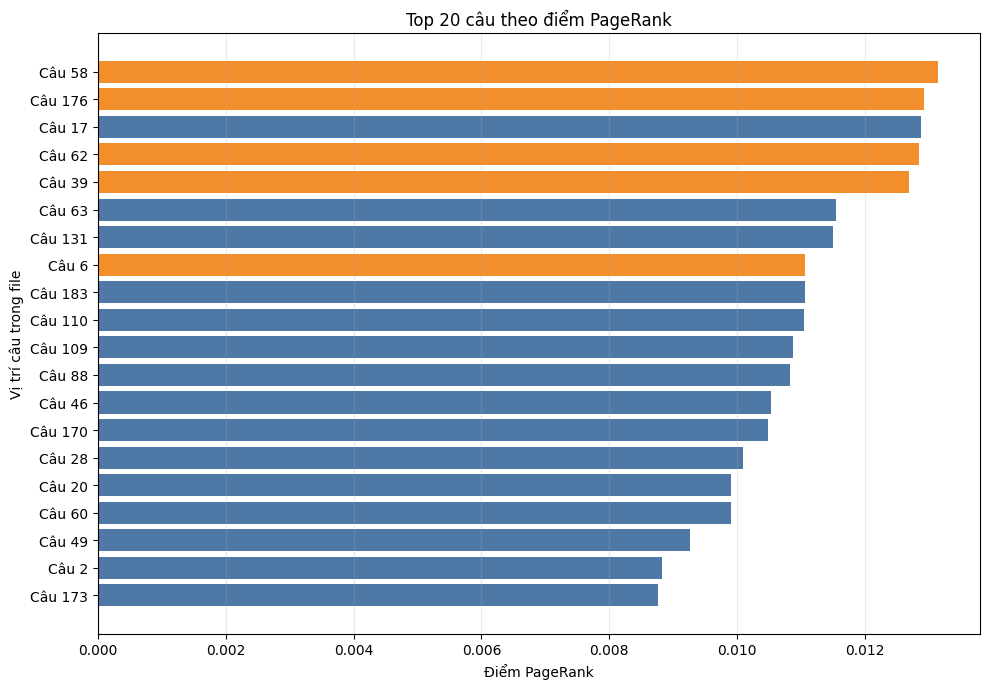

Đã lưu: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/single-document-textrank-visualization/pagerank-top-sentences.png


In [5]:
top_indices = ranked_indices[:TOP_SENTENCES_TO_PLOT]
top_indices_for_chart = list(reversed(top_indices))
bar_colors = [
    '#f28e2b' if index in selected_set else '#4e79a7'
    for index in top_indices_for_chart
]
bar_labels = [f'Câu {index + 1}' for index in top_indices_for_chart]
bar_values = [pagerank_scores[index] for index in top_indices_for_chart]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(bar_labels, bar_values, color=bar_colors)
ax.set_title(f'Top {TOP_SENTENCES_TO_PLOT} câu theo điểm PageRank')
ax.set_xlabel('Điểm PageRank')
ax.set_ylabel('Vị trí câu trong file')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

pagerank_image_path = OUTPUT_DIR / 'pagerank-top-sentences.png'
fig.savefig(pagerank_image_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {pagerank_image_path}')

## 6. Đồ thị liên kết giữa các câu nổi bật

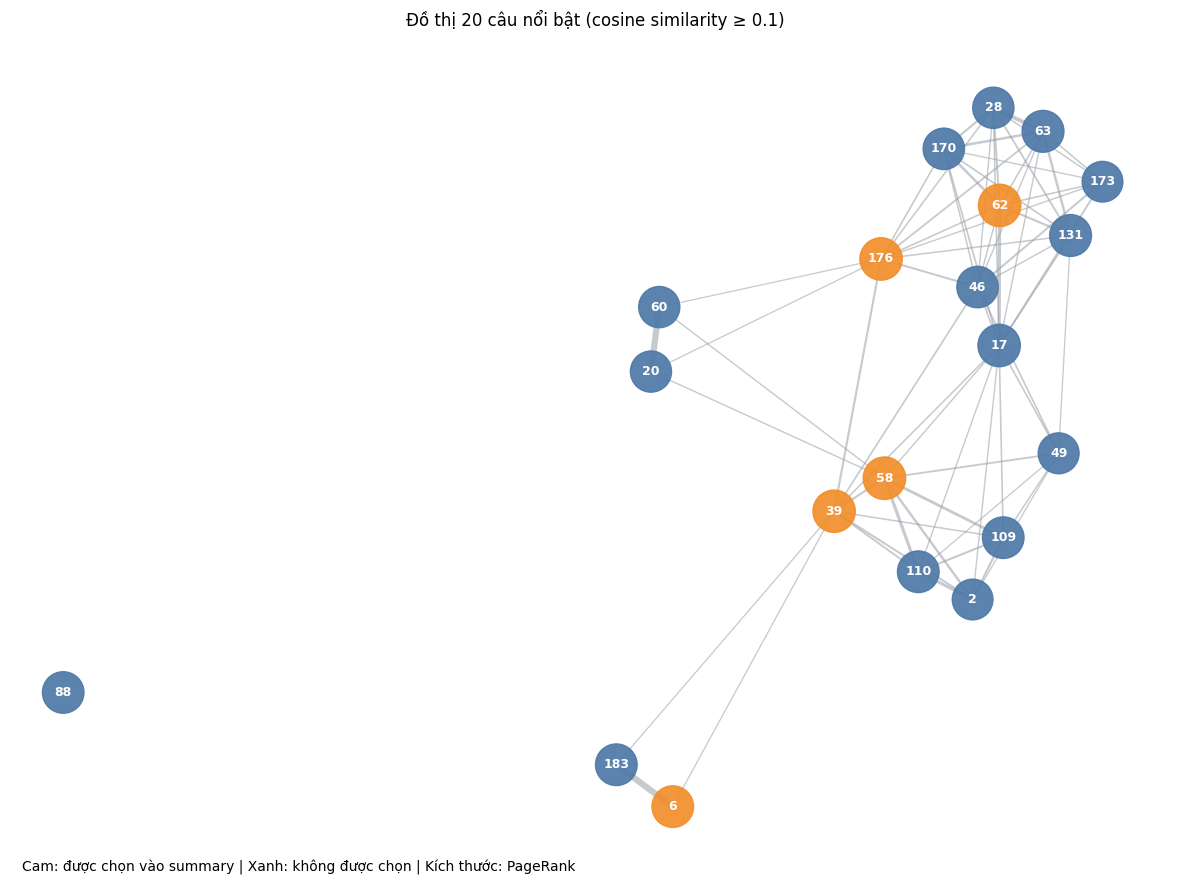

Đã lưu: /Users/thangtran/Workplace/master_s_degree/nlp/nlp-practice/data/output/single-document-textrank-visualization/sentence-network.png


In [6]:
# Chỉ lấy các câu có PageRank cao nhất để hình không bị rối.
visible_nodes = set(top_indices)
graph_to_plot = nx.Graph()

for index in top_indices:
    graph_to_plot.add_node(index)

for left_index in top_indices:
    for right_index, weight in sentence_graph[left_index].items():
        if right_index in visible_nodes and left_index < right_index:
            graph_to_plot.add_edge(left_index, right_index, weight=weight)

positions = nx.spring_layout(graph_to_plot, seed=42, weight='weight')
node_sizes = [
    700 + 18000 * pagerank_scores[index]
    for index in graph_to_plot.nodes
]
node_colors = [
    '#f28e2b' if index in selected_set else '#4e79a7'
    for index in graph_to_plot.nodes
]
edge_widths = [
    0.5 + 4.0 * data['weight']
    for _, _, data in graph_to_plot.edges(data=True)
]
labels = {index: str(index + 1) for index in graph_to_plot.nodes}

fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_nodes(
    graph_to_plot,
    positions,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.92,
    ax=ax,
)
nx.draw_networkx_edges(
    graph_to_plot,
    positions,
    width=edge_widths,
    edge_color='#9aa0a6',
    alpha=0.55,
    ax=ax,
)
nx.draw_networkx_labels(
    graph_to_plot,
    positions,
    labels=labels,
    font_color='white',
    font_weight='bold',
    font_size=9,
    ax=ax,
)
ax.set_title(
    f'Đồ thị {TOP_SENTENCES_TO_PLOT} câu nổi bật '
    f'(cosine similarity ≥ {SIMILARITY_THRESHOLD})'
)
ax.text(
    0.01,
    0.01,
    'Cam: được chọn vào summary | Xanh: không được chọn | Kích thước: PageRank',
    transform=ax.transAxes,
    fontsize=10,
    bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'},
)
ax.axis('off')
fig.tight_layout()

network_image_path = OUTPUT_DIR / 'sentence-network.png'
fig.savefig(network_image_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Đã lưu: {network_image_path}')

## 7. Đọc nhanh kết quả

- Cột dài hơn biểu thị câu có PageRank cao hơn.
- Trong network, cạnh dày hơn biểu thị hai câu giống nhau hơn theo cosine similarity.
- Màu cam cho biết câu đã được MMR chọn vào candidate summary; một câu PageRank cao vẫn có thể bị loại nếu quá trùng lặp hoặc vượt giới hạn số từ.